In [38]:
import pandas as pd
import numpy as np
import geopandas as gpd
# import dask_geopandas as dgpd
import fiona
import rasterio 
import matplotlib.pyplot as plt
import contextily as cx
import rioxarray as rxr

# Next stop - Gewaspercelen
Onderverdelen in: bloementeelt (lelies apart?)
Grasland
Hoogwaardige landbouwgrond

Aantal roulaties?

In [39]:
def convert_to_pmtiles(infile, outgeojson, outfile, layername, maxzoom = 'g'):
    import subprocess

    if infile.crs != "EPSG:4326":
        infile = infile.to_crs(epsg=4326)
    infile.to_file(f"GeoJSON_PMTILES/{outgeojson}.geojson", driver='GeoJSON')
    tippecanoe_path = "/opt/homebrew/bin/tippecanoe" 

    command = [
        tippecanoe_path,
        "-o", f"{outfile}.pmtiles",
        f"--layer={layername}",
        f"-z{maxzoom}",                    # Automatische zoom-inschatting
        "--drop-densest-as-needed", 
        "--force",                
        f"GeoJSON_PMTILES/{outgeojson}.geojson"
    ]

    print("Tippecanoe start met het bakken van de tegels...")

    try:
        result = subprocess.run(command, check=True, capture_output=True, text=True)
        print(f"PMTiles bestand {outfile}.pmtiles is klaar.")
    except subprocess.CalledProcessError as e:
        print("Er ging iets mis met Tippecanoe:")
        print(e.stderr)


In [42]:
gewaspercelen = gpd.read_file('Files/Gewaspercelen/brpgewaspercelen_definitief_2024.gpkg', engine = 'pyogrio')

In [43]:
gewaspercelen.head(2)

,category,gewas,gewascode,jaar,status,geometry
0,Grasland,"Grasland, blijvend",265,2024,Definitief,"POLYGON ((114282.817 444124.593, 114285.99 444..."
1,Landschapselement,Sloot,343,2024,Definitief,"POLYGON ((180470.66 577534.159, 180470.769 577..."


In [63]:
categorieen_gewaspercelen = pd.read_excel('Files/Gewaspercelen/Gewascodes_RVO_indeling.xlsx')
categorieen_gewaspercelen

,gewas,gewascode,RVO_hoofdcategorie
0,Bloemzaden open grond,174,Bloementeelt en boomkwekerijen
1,"Tarwe, winter-",233,Akkerbouw
2,"Tarwe, zomer-",234,Akkerbouw
3,"Gerst, winter-",235,Akkerbouw
4,"Gerst, zomer-",236,Akkerbouw
...,...,...,...
366,Rietland,7127,Overig
367,Rietkraag/rietzoom,7128,Overig
368,"Rogge, groenvoedergewas",7129,Akkerbouw
369,"Rogge, korrelgewas",7130,Akkerbouw


In [65]:
GRASLAND_CATS = categorieen_gewaspercelen[categorieen_gewaspercelen.RVO_hoofdcategorie == 'Grasland']
GRASLAND_CATS

,gewas,gewascode,RVO_hoofdcategorie
16,"Grasland, blijvend",265,Grasland
17,"Grasland, tijdelijk",266,Grasland
23,"Grasland, natuurlijk. Met landbouwactiviteiten.",331,Grasland
24,"Grasland, natuurlijk. Hoofdfunctie natuur.",332,Grasland
358,Stroken wild gras,6807,Grasland


In [ ]:
grasland = gewaspercelen[gewaspercelen.gewascode.isin(GRASLAND_CATS.gewascode)].union_all()

In [ ]:
grasland = gpd.GeoDataFrame([grasland], columns ['geometry'], crs = gewaspercelen.crs)
grasland["category"] = "Grasland"

In [52]:
wb = gpd.read_file('Files/Grootschalige_woningbouwlocaties/Grootschalige_woningbouwlocaties.shp')
from shapely.geometry import Polygon

# Definieer de polygon met tuples (lon, lat)
polygon_coords = [
    (6.0800, 52.5090),  # NW
    (6.1040, 52.5090),  # NE
    (6.1040, 52.4950),  # SE
    (6.0800, 52.4950),  # SW
    (6.0800, 52.5090)   # terug naar NW
]

# Maak een Shapely Polygon object
polygon = Polygon(polygon_coords)

# Vul None waarden in geometry-kolom met deze polygon
wb.geometry = wb.geometry.fillna(polygon)

In [ ]:
def convert_to_pmtiles(infile, outgeojson, outfile, layername, maxzoom = 'g'):
    import subprocess

    if infile.crs != "EPSG:4326":
        infile = infile.to_crs(epsg=4326)
    infile.to_file(f"GeoJSON_PMTILES/{outgeojson}.geojson", driver='GeoJSON')
    tippecanoe_path = "/opt/homebrew/bin/tippecanoe" 

    command = [
        tippecanoe_path,
        "-o", f"{outfile}.pmtiles",
        f"--layer={layername}",
        f"-z{maxzoom}",                    # Automatische zoom-inschatting
        "--drop-densest-as-needed", 
        "--force",                
        f"GeoJSON_PMTILES/{outgeojson}.geojson"
    ]

    print("Tippecanoe start met het bakken van de tegels...")

    try:
        result = subprocess.run(command, check=True, capture_output=True, text=True)
        print(f"PMTiles bestand {outfile}.pmtiles is klaar.")
    except subprocess.CalledProcessError as e:
        print("Er ging iets mis met Tippecanoe:")
        print(e.stderr)


In [53]:
convert_to_pmtiles(wb, 'Woningbouw', 'Woningbouw', 'Woningbouw')

Tippecanoe start met het bakken van de tegels...
PMTiles bestand Woningbouw.pmtiles is klaar.


In [52]:
convert_to_pmtiles(gdf_n2000_original_geom[['nr', 'geometry']], 'N2000', 'N2000', 'N2000')

Tippecanoe start met het bakken van de tegels...
PMTiles bestand 'veenweide.pmtiles' is klaar.


In [17]:
if veenweide_polygons.crs != "EPSG:4326":
    veenweide_polygons = veenweide_polygons.to_crs(epsg=4326)
veenweide_polygons.to_file("GeoJSON_PMTILES/veenweide_temp.geojson", driver='GeoJSON')

In [53]:
waterschap : gpd.GeoDataFrame = gpd.read_file('Files/Kartering/waterschap.gpkg', use_arrow=True, engine='pyogrio')
convert_to_pmtiles(waterschap, 'Waterschap', 'Waterschap', 'Waterschap')

Tippecanoe start met het bakken van de tegels...
PMTiles bestand 'veenweide.pmtiles' is klaar.


In [54]:
gdf_provincies : gpd.GeoDataFrame = gpd.read_file('Files/Kartering/cbsgebiedsindelingen2025.gpkg', layer='provincie_gegeneraliseerd', use_arrow=True, engine='pyogrio')
convert_to_pmtiles(gdf_provincies, 'Provincies', 'Provincies', 'Provincies')

Tippecanoe start met het bakken van de tegels...
PMTiles bestand 'veenweide.pmtiles' is klaar.


In [18]:
import subprocess

tippecanoe_path = "/opt/homebrew/bin/tippecanoe" 

command = [
    tippecanoe_path,
    "-o", "veenweide.pmtiles",
    "--layer=veenweide_laag",
    "-zg",                    # Automatische zoom-inschatting
    "--drop-densest-as-needed", 
    "--force",                
    "GeoJSON_PMTILES/veenweide_temp.geojson"
]

print("Tippecanoe start met het bakken van de tegels...")

try:
    result = subprocess.run(command, check=True, capture_output=True, text=True)
    print("PMTiles bestand 'veenweide.pmtiles' is klaar.")
except subprocess.CalledProcessError as e:
    print("Er ging iets mis met Tippecanoe:")
    print(e.stderr)


Tippecanoe start met het bakken van de tegels...
PMTiles bestand 'veenweide.pmtiles' is klaar.


✅ index.html is gegenereerd.


Html(children=[<leafmap.maplibregl.Map object at 0x10a76de00>, Card(children=[Btn(children=[Icon(children=['md…

In [15]:
from pmtiles.reader import Reader
import os

def check_pmtiles_fixed(file_path):
    if not os.path.exists(file_path):
        print(f"Bestand {file_path} niet gevonden!")
        return

    # We openen het bestand met een context manager en geven de file-pointer direct door
    with open(file_path, "rb") as f:
        reader = Reader(f)
        header = reader.header()
        
        print(f"--- Analyse van: {file_path} ---")
        print(f"Grootte: {os.path.getsize(file_path) / 1024 / 1024:.2f} MB")
        
        # Check de coördinaten
        print(f"\n📍 COÖRDINATEN (Bounds):")
        print(f"West: {header.min_lon}, Zuid: {header.min_lat}")
        print(f"Oost: {header.max_lon}, Noord: {header.max_lat}")
        
        if header.min_lon > 180 or header.min_lat > 90:
            print("\n⚠️  ALARM: De getallen zijn te hoog! Je data staat in Rijksdriehoekstelsel (RD).")
            print("Tippecanoe begrijpt dit niet. Je moet je GeoJSON eerst omzetten naar EPSG:4326.")
        else:
            print("\n✅ De coördinaten lijken in het juiste formaat (WGS84) te staan.")

        # Check de zoomniveaus
        print(f"\n🔍 ZOOMNIVEAUS:")
        print(f"Zichtbaar tussen zoom {header.min_zoom} en {header.max_zoom}")
        
        # Check de lagen (metadata)
        try:
            metadata = reader.metadata()
            if 'vector_layers' in metadata:
                print(f"\nlayers 📚 LAGEN:")
                for layer in metadata['vector_layers']:
                    print(f"- Laagnaam in bestand: '{layer['id']}'")
            else:
                print("\n❓ Geen vector_layers gevonden in metadata.")
        except Exception as e:
            print(f"\nMetadata kon niet gelezen worden: {e}")

check_pmtiles_fixed("veenweide.pmtiles")

TypeError: '_io.BufferedReader' object is not callable

In [33]:
import leafmap.maplibregl as lm

# 1. Basemap
m = lm.Map(
    style="https://basemaps.cartocdn.com/gl/positron-gl-style/style.json",
    center=[5.1, 52.1],
    zoom=8
)

# 2. GEEN add_pmtiles hier (belangrijk)
html_raw = m.to_html()

# 3. Injecteer PMTiles + layer zelf
pmtiles_bundle = """
<link href="https://cdn.jsdelivr.net/npm/maplibre-gl@5.21.1/dist/maplibre-gl.css" rel="stylesheet" />
<script src="https://cdn.jsdelivr.net/npm/maplibre-gl@5.21.1/dist/maplibre-gl.js"></script>
<script src="https://cdn.jsdelivr.net/npm/pmtiles@4.4.0/dist/pmtiles.min.js"></script>

<script>
document.addEventListener("DOMContentLoaded", function () {

    const waitForMap = setInterval(() => {
        if (window.map) {
            clearInterval(waitForMap);

            // 1. PMTiles protocol registreren
            const protocol = new pmtiles.Protocol();
            maplibregl.addProtocol("pmtiles", protocol.tile);

            const url = window.location.origin + window.location.pathname.replace("index.html","") + "veenweide.pmtiles";
            const p = new pmtiles.PMTiles(url);
            protocol.add(p);

            // 2. Source toevoegen
            map.addSource("veenweide", {
                type: "vector",
                url: "pmtiles://" + url
            });

            // 3. Layer toevoegen (POLYGONS!)
            map.addLayer({
                id: "veenweide_laag",
                type: "fill",
                source: "veenweide",
                "source-layer": "veenweide_laag",
                paint: {
                    "fill-color": "#8d6e63",
                    "fill-opacity": 0.6
                }
            });

        }
    }, 100);
});
</script>
"""

# 4. Injectie
final_html = html_raw.replace("<head>", f"<head>\n{pmtiles_bundle}")

# 5. Opslaan
with open("index.html", "w") as f:
    f.write(final_html)

print("Klaar.")

Klaar.


In [37]:
# Definieer je laagnaam (zoals bekend in de pmtiles file)
laagnaam_uit_pmtiles = "veenweide_laag"

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Veenweide Kaart</title>
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <link rel="stylesheet" href="https://unpkg.com/maplibre-gl@4.7.1/dist/maplibre-gl.css" />
    <style>
        body {{ margin: 0; padding: 0; }}
        #map {{ position:absolute; top:0; bottom:0; width:100%; }}
    </style>
</head>
<body>
    <div id="map"></div>
    
    <script src="https://unpkg.com/maplibre-gl@4.7.1/dist/maplibre-gl.js"></script>
    <script src="https://unpkg.com/pmtiles@3.2.0/dist/index.js"></script>
    
    <script>
        // 1. Setup PMTiles Protocol
        const protocol = new pmtiles.Protocol();
        maplibregl.addProtocol("pmtiles", protocol.add);

        // 2. Definieer de URL van het bestand (relatief aan de index.html op GitHub)
        const pmtiles_url = window.location.href.substring(0, window.location.href.lastIndexOf("/")) + "/veenweide.pmtiles";

        // 3. Initialiseer de kaart met een standaard Carto stijl (zodat je in ieder geval een basiskaart ziet)
        const map = new maplibregl.Map({{
            container: 'map',
            style: 'https://basemaps.cartocdn.com/gl/positron-gl-style/style.json',
            center: [5.1, 52.1],
            zoom: 8
        }});

        map.on('load', () => {{
            // 4. Voeg de PMTiles bron toe
            map.addSource('veenweide_source', {{
                type: 'vector',
                url: 'pmtiles://' + pmtiles_url
            }});

            // 5. Voeg de laag toe
            map.addLayer({{
                'id': 'veenweide_visual',
                'type': 'fill',
                'source': 'veenweide_source',
                'source-layer': '{laagnaam_uit_pmtiles}',
                'paint': {{
                    'fill-color': '#88cc88',
                    'fill-opacity': 0.5,
                    'fill-outline-color': '#ffffff'
                }}
            }});
        }});

        // Foutopsporing
        map.on('error', (e) => {{
            console.error('MapLibre fout:', e);
        }});
    </script>
</body>
</html>
"""

with open("index.html", "w") as f:
    f.write(html_content)

print("Bestand 'index.html' is gegenereerd. Push deze en 'veenweide.pmtiles' naar GitHub.")

Bestand 'index.html' is gegenereerd. Push deze en 'veenweide.pmtiles' naar GitHub.


In [77]:
# Woningbouw
import matplotlib.pyplot as plt
import contextily as cx

# Provincies
gdf_provincies : gpd.GeoDataFrame = gpd.read_file('Files/Kartering/cbsgebiedsindelingen2025.gpkg', layer='provincie_gegeneraliseerd', use_arrow=True, engine='pyogrio')

# Regionale wb
regionale_wb = gpd.read_file('Files/regionale_woningbouwlocaties/regionale_woningbouwlocaties.shp')

# Grootschalige wb
wb = gpd.read_file('Files/Grootschalige_woningbouwlocaties/Grootschalige_woningbouwlocaties.shp')
from shapely.geometry import Polygon

# Definieer de polygon met tuples (lon, lat)
polygon_coords = [
    (6.0800, 52.5090),  # NW
    (6.1040, 52.5090),  # NE
    (6.1040, 52.4950),  # SE
    (6.0800, 52.4950),  # SW
    (6.0800, 52.5090)   # terug naar NW
]

# Maak een Shapely Polygon object
polygon = Polygon(polygon_coords)

# Vul None waarden in geometry-kolom met deze polygon
wb.geometry = wb.geometry.fillna(polygon)

# Stikstofgevoelige N2000
n2000_loc = 'Files/Kartering/natura2000.gpkg'
n2000 = gpd.read_file(n2000_loc, engine = 'pyogrio')
n2000_dissolved : gpd.GeoDataFrame = n2000.copy().dissolve(by='nr', as_index=False)
n2000_dissolved.head(5)
grote_wateren = [1, 7, 72, 73, 74, 75, 76, 77, 108, 109, 111, 113, 114, 115, 118, 119, 120, 122, 152, 163, 164, 165, 166, 167, 168]

gdf_koppeltabel : gpd.GeoDataFrame = gpd.read_file('Files/Aerius/hexagons_to_relevant_habitats-2025.xml', use_arrow=True, engine='pyogrio')
gdf_koppeltabel = gdf_koppeltabel[gdf_koppeltabel['zoom_level'] == 1] # beperken tot enkel individuele hexagonen
gdf_n2000_subset = n2000_dissolved[n2000_dissolved.nr.isin(gdf_koppeltabel.natura2000_area_id)]

n2000_dissolved = gdf_n2000_subset[~gdf_n2000_subset.nr.isin(grote_wateren)]
n2000_dissolved['buffered_geom'] = n2000_dissolved.buffer(1000)
gdf_n2000_original_geom = n2000_dissolved.set_geometry('geometry')
gdf_n2000_buffer_geom = n2000_dissolved.set_geometry('buffered_geom')

bufferstrook = gdf_n2000_buffer_geom.overlay(gdf_n2000_original_geom, how='difference')

/Users/j.vanmaanen1/venvs/myvenv/lib/python3.13/site-packages/geopandas/geodataframe.py:1969: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


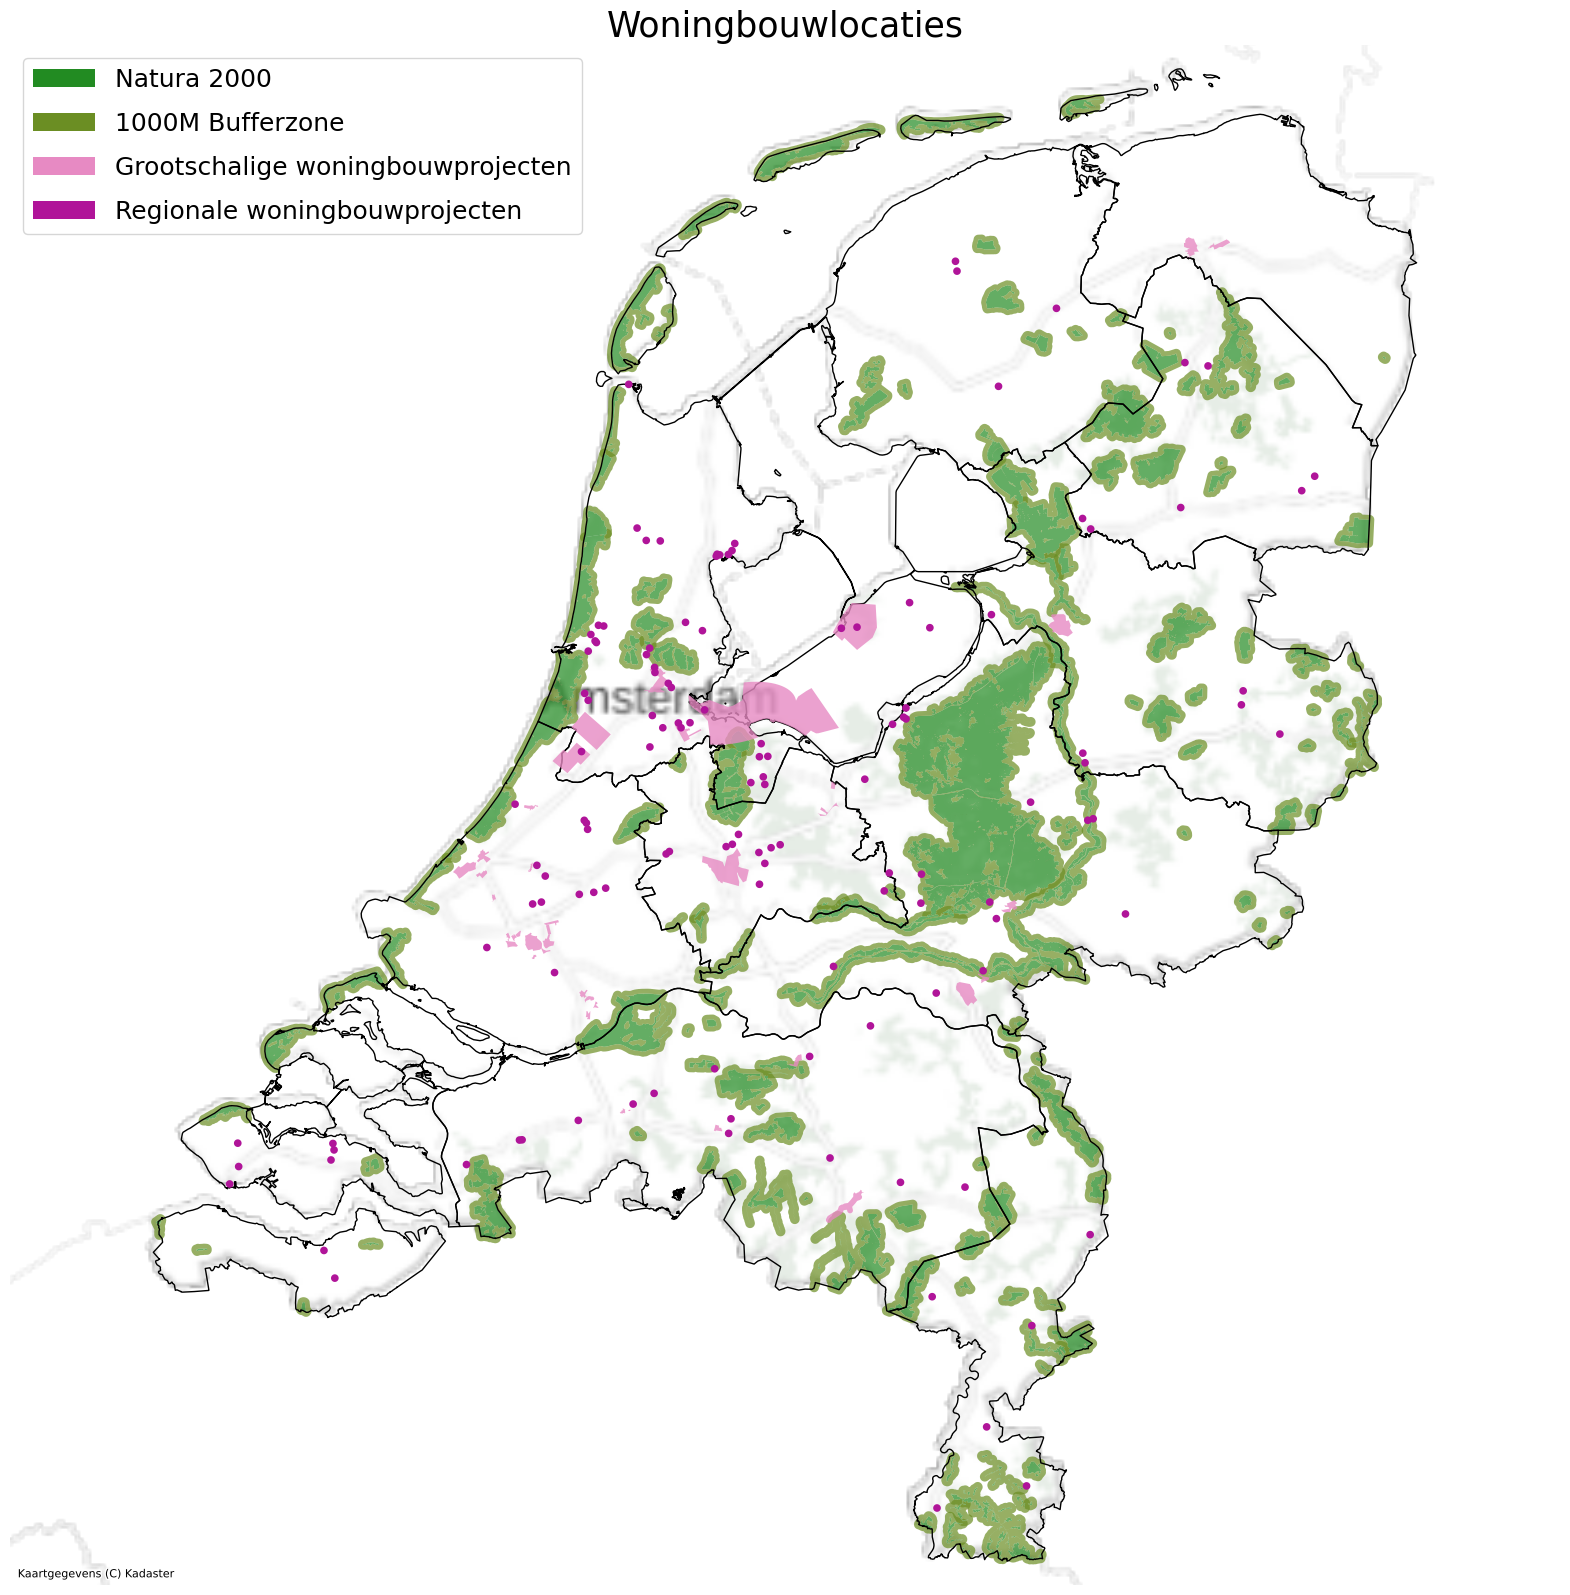

In [96]:
fig, axs = plt.subplots(figsize=(20,20))
axs.axis('equal')

gdf_n2000_original_geom.plot(ax=axs, facecolor='#228B22', edgecolor='None', alpha=0.7)
bufferstrook.plot(ax=axs, facecolor='#6B8E23', edgecolor='None', alpha=0.7)
gdf_provincies.plot(ax=axs, facecolor='None', edgecolor='black')

wb.plot(ax=axs, facecolor='#e78ac3', edgecolor='None', alpha=0.8)
regionale_wb.buffer(800).plot(ax=axs, facecolor='#B01499', edgecolor='None')

cx.add_basemap(axs, 
    crs=gdf_provincies.crs.to_string(),
    source=cx.providers.nlmaps.grijs
)

# Bereken de grenzen (bounds) van Nederland op basis van je provincie-layer
minx, miny, maxx, maxy = gdf_provincies.total_bounds

# Stel de limieten in met een kleine marge (bijv. 5000 meter als je RD-coördinaten gebruikt)
axs.set_xlim(minx - 5000, maxx + 5000)
axs.set_ylim(miny - 5000, maxy + 5000)

import matplotlib.patches as mpatches

legend = [
    mpatches.Patch(facecolor='#228B22', label='Natura 2000'),
    mpatches.Patch(facecolor='#6B8E23', label='1000M Bufferzone'),
    mpatches.Patch(facecolor='#e78ac3', label='Grootschalige woningbouwprojecten'),
    mpatches.Patch(facecolor='#B01499', label='Regionale woningbouwprojecten'),
]

axs.legend(
    handles=legend,
    loc='upper left',
    fontsize='18', 
    handlelength=2.5,   
    labelspacing=0.8,  
    frameon=True       
)

plt.title('Woningbouwlocaties', fontsize = 25)
plt.axis('off')
plt.show()

# Depositiepotentie

In [15]:
import numpy as np
import geopandas as gpd
import pandas as pd
gdf_koppeltabel : gpd.GeoDataFrame = gpd.read_file('Files/Aerius/hexagons_to_relevant_habitats-2024.xml', use_arrow=True, engine='pyogrio')

unique_habitats = np.unique(gdf_koppeltabel[['natura2000_area_id', 'habitat_type_id']], axis=0)

df_habitats : pd.DataFrame = pd.DataFrame.from_dict({'n2000_id' : unique_habitats[:,0],
                                                    'habitat_id' : unique_habitats[:,1]})

n2000_name_list = pd.read_excel('Files/Aerius/Stikstof_DASH-2024_N2KnamenLijst_20250207.xlsx')
habitat_name_list = pd.read_excel('Files/Aerius/Stikstof_DASH-2024_HabitattypeLijst_20250207.xlsx')

df_habitats = df_habitats.merge(n2000_name_list, left_on='n2000_id', right_on='natura2000_area_id', how='left')
df_habitats = df_habitats.merge(habitat_name_list, left_on='habitat_id', right_on='habitat_type_id', how='left').drop(columns=['natura2000_area_id', 'habitat_type_id']) 

df_habitats['UID'] = df_habitats.apply(lambda row: f"{row['n2000_id']}_{row['habitat_id']}", axis=1)
df_habitats.describe()

,n2000_id,habitat_id
count,1383.000000,1383.000000
mean,74.893709,133.081706
std,48.318988,75.141640
min,1.000000,20.000000
25%,34.000000,73.000000
50%,70.000000,126.000000
75%,118.000000,190.000000
max,167.000000,590.000000


In [5]:
def construct_matrix_A(sectorlist : list) -> pd.DataFrame:
    df_A : pd.DataFrame = pd.DataFrame(index=emission_grid_ids, columns=habitat_ids)
    
    for col in df_A.columns:
        n2000_id, habitat_id = col.split('_')
        filename = f'{WORKING_DIR}/{n2000_id}_{habitat_id}.parquet'
        depo_df = pd.read_parquet(filename).set_index('location_id')
        
        #maak zeker dat de indices overeen komen en goed worden toegewezen, verder selecteer alleen gemiddelde deposities van relevante sectoren
        df_A[col] = depo_df.reindex(df_A.index)[[f'{sector}_avg' for sector in sectorlist]].sum(axis=1)  
    
    df_A = df_A.copy() #defragmentaliseer dataframe

    return df_A

In [ ]:
import re
dash_sectoren = pd.read_excel('Files/Aerius/Stikstof_DASH-2024_DASHSectorLijst_20250207.xlsx')
LANDBOUW_CODES = list(filter(re.compile('lb*').match, list(dash_sectoren['dash_sector_code'])))
LANDBOUW_CODES.remove('lbpar')

df_example_emission = pd.read_parquet('Files/Aerius/Deposities_per_habitattype/totaal/nl/depositions_1_20.parquet') #indeling alle parquet files zijn identiek
habitat_ids = np.array(df_habitats['UID']); emission_grid_ids = np.array(df_example_emission['location_id'])
WORKING_DIR = 'Files/Aerius/Deposities_per_habitattype/totaal/nl'

def construct_matrix_A(sectorlist : list) -> pd.DataFrame:
    df_A : pd.DataFrame = pd.DataFrame(index=emission_grid_ids, columns=habitat_ids)
    
    for col in df_A.columns:
        n2000_id, habitat_id = col.split('_')
        filename = f'{WORKING_DIR}/depositions_{n2000_id}_{habitat_id}.parquet'
        depo_df = pd.read_parquet(filename).set_index('location_id')
        
        #maak zeker dat de indices overeen komen en goed worden toegewezen, verder selecteer alleen gemiddelde deposities van relevante sectoren
        df_A[col] = depo_df.reindex(df_A.index)[[f'{sector}_avg' for sector in sectorlist]].sum(axis=1)  
    
    df_A = df_A.copy() #defragmentaliseer dataframe

    return df_A
df_A = construct_matrix_A(sectorlist=LANDBOUW_CODES)
df_A

,1_20,1_22,1_26,1_28,1_30,1_34,1_36,1_37,1_38,1_40,...,160_128,160_134,160_151,160_190,160_198,161_184,161_198,161_210,167_150,167_208
536,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7004,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
47778,0.001,0.000,0.001,0.004,0.018,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
19812,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
34354,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26263,0.000,0.000,0.000,0.000,0.001,0.000,0.000,0.000,0.000,0.000,...,0.001,0.001,0.001,0.002,0.001,0.000,0.001,0.000,0.000,0.000
32421,0.109,0.040,0.102,0.085,0.031,0.074,0.082,0.007,0.044,0.094,...,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.000,0.000
36897,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
14886,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,...,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.003,0.001,0.001


In [89]:
gdf_emission_grid_dash = gpd.read_file('Files/Aerius/Geografie/Stikstof_DASH-2024_Geografie_20250207.gpkg')


In [18]:
#nodig om NOx-emissies en NH3-emissies om te rekenen in mol/jaar

#bron: wikipedia
MOLAR_MASS_N = 14.0067  #gram/mol
MOLAR_MASS_H = 1.0079   #gram/mol
MOLAR_MASS_O = 15.999   #gram/mol

MOLAR_MASS_NH3 = MOLAR_MASS_N + MOLAR_MASS_H * 3
MOLAR_MASS_NOx = MOLAR_MASS_N + MOLAR_MASS_O * 2

In [19]:
dash_emissions_nox = gpd.read_file("./Files/Emissies/Stikstof_DASH-2024_Emissies_20250207.gpkg", layer='location_emissions_nox')
dash_emissions_nh3 = gpd.read_file("./Files/Emissies/Stikstof_DASH-2024_Emissies_20250207.gpkg", layer='location_emissions_nh3')

dash_emissions_nox['location_id'] = dash_emissions_nox['location_id'].astype(int)
dash_emissions_nh3['location_id'] = dash_emissions_nh3['location_id'].astype(int)

dash_emissions_nox = dash_emissions_nox.set_index('location_id').reindex(df_A.index)[LANDBOUW_CODES].sum(axis=1) * 1_000 / MOLAR_MASS_NOx
dash_emissions_nh3 = dash_emissions_nh3.set_index('location_id').reindex(df_A.index)[LANDBOUW_CODES].sum(axis=1) * 1_000 / MOLAR_MASS_NH3

total_emissions = dash_emissions_nox + dash_emissions_nh3
df_dp = df_habitats.copy().set_index('UID')

In [ ]:
# DP per hexagon berekenen als ratio deposities emissies
# Landelijk gemiddelde berekenen

# NEE DIT IS TE SIMPEL. WANT HET GAAT OM DE DP OP STIKSTOFGEVOELIGE NATUUR. OF EIGENLIJK OP OVERBELASTE NATUUR
# Maar: het extensiveren van 1 hexagon zou de dp van een ander hexagon niet mogen beinvloeden. Immers, je kunt er ook voor kiezen om in hexagon 2 maatregelen te nemen


536       56794.110233
7004      22821.395180
47778     93020.731588
19812         0.000000
34354         5.871853
             ...      
26263    173502.977083
32421    413237.121292
36897     49364.211181
14886    244502.071475
1014          0.000000
Length: 43838, dtype: float64

In [45]:
deposities_per_hexagon = df_A.sum(axis = 1) * 1000

In [49]:
df_A.loc[46345].sum()

np.float32(0.001)

In [32]:
dp_df = pd.concat([total_emissions, deposities_per_hexagon], axis = 1)

In [33]:
dp_df.columns = ["Emissie", 'Depositie']

In [63]:
def calculate_depositiepotentie(row):
    emissie = row['Emissie']
    depositie = row['Depositie']

    if emissie == 0:
        return 0
    else:
        return depositie/emissie
    
dp_df['depositiepotentie'] = dp_df.apply(calculate_depositiepotentie, axis =1)

In [64]:
dp_df['depositiepotentie_tov_landelijk'] = dp_df['depositiepotentie']/LANDELIJK_DP

In [65]:
dp_df_subset = dp_df[dp_df.depositiepotentie != 0]

In [66]:
LANDELIJK_DP = np.sum(dp_df_subset.Emissie)/np.sum(dp_df_subset.Depositie)
LANDELIJK_DP

np.float64(10.529109189902963)

In [67]:
dp_df.sort_values('depositiepotentie')

,Emissie,Depositie,depositiepotentie,depositiepotentie_tov_landelijk
8934,0.000000,0.000000,0.000000,0.000000
1267,0.000000,0.000000,0.000000,0.000000
894,0.000000,0.000000,0.000000,0.000000
4178,0.000000,0.000000,0.000000,0.000000
7822,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...
10141,7245.938011,62131.992188,8.574734,0.814384
32502,8080.947980,69883.968750,8.647991,0.821341
41722,19691.470902,185469.078125,9.418752,0.894544
46653,2678.209106,27666.996094,10.330409,0.981129


In [90]:
gdf_emission_grid_dash


,location_id,vk_ai_code,provincie_naam,geometry
0,3,+000+395km5,Continentaal Plat,"POLYGON ((4999.999 399999.999, 4999.999 394999..."
1,4,+000+400km5,Continentaal Plat,"POLYGON ((4999.999 404999.999, 4999.999 399999..."
2,5,+000+405km5,Continentaal Plat,"POLYGON ((4999.999 404999.999, -0.001 405000, ..."
3,6,+000+410km5,Continentaal Plat,"POLYGON ((4999.999 409999.999, -0.001 409999.9..."
4,7,+000+415km5,Continentaal Plat,"POLYGON ((4999.998 420000, 4999.998 415000.001..."
...,...,...,...,...
48934,48891,279551km1,Groningen,"POLYGON ((280000 551000, 279000 551000, 279000..."
48935,48897,279557km1,Groningen,"POLYGON ((280000 557000, 279000 557000, 279000..."
48936,48913,279573km1,Groningen,"POLYGON ((280000 573000, 279000 573000, 279000..."
48937,48929,279589km1,Groningen,"POLYGON ((280000 589000, 279000 589000, 279000..."


In [91]:
dp_df_plot = gdf_emission_grid_dash.merge(dp_df, right_index = True, left_on = 'location_id')

In [92]:
dp_df_plot

,location_id,vk_ai_code,provincie_naam,geometry,Emissie,Depositie,depositiepotentie,depositiepotentie_tov_landelijk
0,3,+000+395km5,Continentaal Plat,"POLYGON ((4999.999 399999.999, 4999.999 394999...",0.000000,0.000000,0.000000,0.000000
1,4,+000+400km5,Continentaal Plat,"POLYGON ((4999.999 404999.999, 4999.999 399999...",0.000000,0.000000,0.000000,0.000000
2,5,+000+405km5,Continentaal Plat,"POLYGON ((4999.999 404999.999, -0.001 405000, ...",0.000000,0.000000,0.000000,0.000000
3,6,+000+410km5,Continentaal Plat,"POLYGON ((4999.999 409999.999, -0.001 409999.9...",0.000000,0.000000,0.000000,0.000000
4,7,+000+415km5,Continentaal Plat,"POLYGON ((4999.998 420000, 4999.998 415000.001...",0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...
48910,48039,266594km1,Groningen,"POLYGON ((267000.001 594000, 266000 594000, 26...",0.000000,0.000000,0.000000,0.000000
48912,48162,268472km1,Overijssel,"POLYGON ((269000 472000, 268000 472000, 268000...",22830.204663,1526.001709,0.066841,0.006348
48914,48203,268528km1,Drenthe,"POLYGON ((269000 528000, 268000 528000, 268000...",34922.810983,399.998383,0.011454,0.001088
48928,48823,277583km1,Groningen,"POLYGON ((278000 583000, 277000 583000, 277000...",374.245230,0.000000,0.000000,0.000000


In [6]:
gdf_provincies : gpd.GeoDataFrame = gpd.read_file('Files/Kartering/cbsgebiedsindelingen2025.gpkg', layer='provincie_gegeneraliseerd', use_arrow=True, engine='pyogrio')
gdf_provincies.crs

<Projected CRS: EPSG:28992>
Name: Amersfoort / RD New
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: Netherlands - onshore, including Waddenzee, Dutch Wadden Islands and 12-mile offshore coastal zone.
- bounds: (3.2, 50.75, 7.22, 53.7)
Coordinate Operation:
- name: RD New
- method: Oblique Stereographic
Datum: Amersfoort
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

In [2]:
import geopandas as gpd
deppot = gpd.read_file("Files/km1_deposition_efficiency.gpkg", engine = "pyogrio")

In [14]:
gemiddeld = deppot[deppot.deposition_efficiency > 0.005].deposition_efficiency.mean()
gemiddeld

np.float64(0.019944940489751657)

In [35]:
subset = deppot[deppot.deposition_efficiency > 3 * gemiddeld].sort_values('deposition_efficiency')

In [36]:
subset['geometry'] = subset.buffer(500)

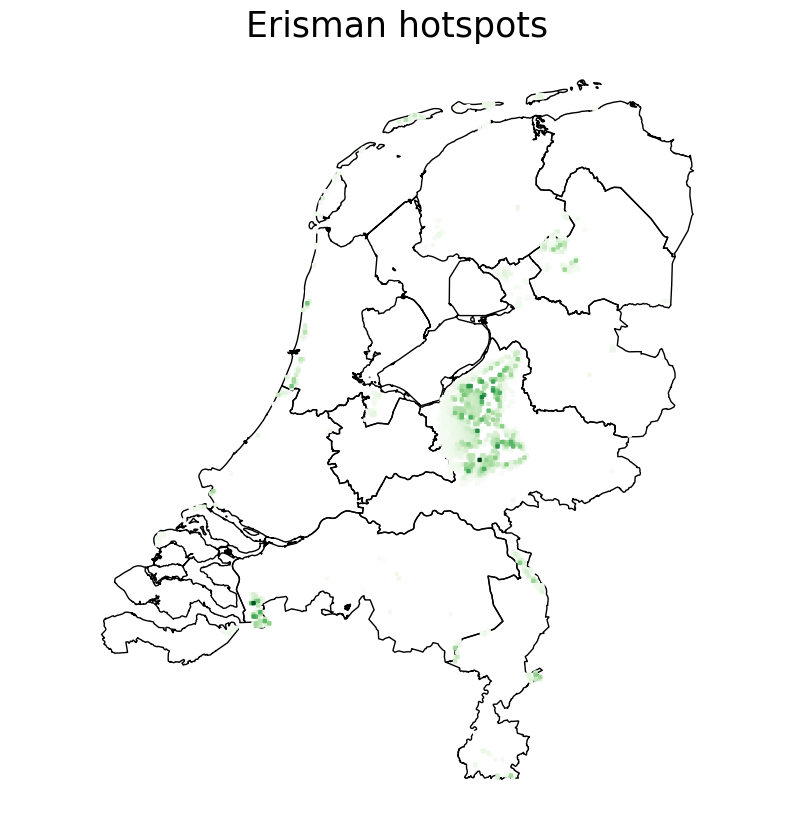

In [37]:
import matplotlib.pyplot as plt
import contextily as cx

fig, axs = plt.subplots(figsize=(10,10))
axs.axis('equal')

# gdf_n2000_original_geom.plot(ax=axs, facecolor='#228B22', edgecolor='None', alpha=0.7)
# bufferstrook.plot(ax=axs, facecolor='#6B8E23', edgecolor='None', alpha=0.7)
gdf_provincies.plot(ax=axs, facecolor='None', edgecolor='black')

subset.plot(ax = axs, column = 'deposition_efficiency', cmap = 'Greens')

# wb.plot(ax=axs, facecolor='#e78ac3', edgecolor='None', alpha=0.8)
# regionale_wb.buffer(800).plot(ax=axs, facecolor='#B01499', edgecolor='None')

# cx.add_basemap(axs, 
#     crs=gdf_provincies.crs.to_string(),
#     source=cx.providers.nlmaps.grijs
# )


plt.title('Erisman hotspots', fontsize = 25)
plt.axis('off')
plt.show()